<a href="https://colab.research.google.com/github/chavacodezen/Maestria-IA/blob/main/Proyecto_Etapa_3_Modelo_Predictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Etapa 3 — Modelo Predictivo**

---

## Alumno

**Nombre:** Bryan Fernando Chavarria Martinez

**Matrícula:** 268838

---

## Dataset

**Nombre:** Homicidios en México — Víctimas por Entidad Federativa

**Fuente:** Kaggle — aalcaide/datos-mexico

**URL:** https://www.kaggle.com/datasets/aalcaide/datos-mexico

**Origen:** Datos oficiales del Secretariado Ejecutivo del Sistema Nacional de
Seguridad Pública (SESNSP) e Instituto Nacional de Estadística y Geografía (INEGI)

**Registros:** 66,240 (SESNSP) + 1,465,607 (Censo Poblacional INEGI 2020)

**Dataset modelado:** 3,456 registros

**Variables principales:** Entidad, año, tipo de delito, modalidad, sexo,
rango de edad, víctimas por mes

**Periodo:** 2015 – 2023

---

## Pregunta de negocio

> **¿Cuál será la tasa de homicidios por cada 100,000 habitantes en una entidad
> federativa de México, dado su historial de violencia, modalidad del delito,
> perfil de las víctimas y contexto temporal?**

Esta pregunta tiene aplicación directa en política pública y seguridad nacional.
Un modelo predictivo de esta naturaleza permite a dependencias como la Secretaría
de Seguridad y Protección Ciudadana (SSPC) o gobiernos estatales anticipar zonas
de alto riesgo, optimizar la asignación de recursos policiales y diseñar
intervenciones focalizadas antes de que los índices de violencia escalen.

---

## Tipo de problema

**Regresión** — la variable objetivo es la tasa de homicidios por cada 100,000
habitantes (`tasa_homicidios`), una variable continua construida a partir del
total de víctimas registradas por entidad, año y mes, normalizada con datos
poblacionales del Censo INEGI 2020.

In [22]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Estilo de visualizaciones
sns.set_theme(style="whitegrid", palette="muted")
pd.options.display.float_format = '{:,.4f}'.format

# Ruta base
from google.colab import drive
drive.mount('/content/drive')
RUTA = "/content/drive/MyDrive/ClassFiles/ProyectoFinal/"

print("Librerías importadas correctamente")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Librerías importadas correctamente


In [23]:
# ── Archivos Fuente ───────────────────────────────────────────────────────────
df_sesnsp = pd.read_parquet(RUTA + "Estatal-Vctimas-2015-2023_dic2023.parquet")
df_censo  = pd.read_parquet(RUTA + "inegi_2020_censo_pob.parquet")

# ── Filtrar solo homicidios ───────────────────────────────────────────
df_hom = df_sesnsp[df_sesnsp['Tipo de delito'] == 'Homicidio'].copy()

meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
         'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
orden_meses = {m: i+1 for i, m in enumerate(meses)}

df_hom['total_anual'] = df_hom[meses].sum(axis=1)

# ── Melt — una fila por entidad/año/mes ───────────────────────────────
df_long = df_hom.melt(
    id_vars=['Año','Clave_Ent','Entidad',
             'Subtipo de delito','Modalidad','Sexo','total_anual'],
    value_vars=meses,
    var_name='Mes',
    value_name='Victimas'
)
df_long['Mes_num'] = df_long['Mes'].map(orden_meses)

# ── Total víctimas por entidad + año + mes ────────────────────────────
df_agg = (
    df_long.groupby(['Año','Mes','Mes_num','Clave_Ent','Entidad'], as_index=False)
    ['Victimas'].sum()
    .rename(columns={'Victimas':'total_victimas'})
)

doloso_mes = (
    df_long[df_long['Subtipo de delito'] == 'Homicidio doloso']
    .groupby(['Año','Mes','Clave_Ent','Entidad'], as_index=False)['Victimas']
    .sum()
    .rename(columns={'Victimas':'victimas_doloso'})
)
df_agg = df_agg.merge(doloso_mes, on=['Año','Mes','Clave_Ent','Entidad'], how='left')
df_agg['victimas_doloso'] = df_agg['victimas_doloso'].fillna(0)
df_agg['pct_hom_doloso'] = df_agg['victimas_doloso'] / df_agg['total_victimas']

masculino_mes = (
    df_long[df_long['Sexo'] == 'Hombre']
    .groupby(['Año','Mes','Clave_Ent','Entidad'], as_index=False)['Victimas']
    .sum()
    .rename(columns={'Victimas':'victimas_hombre'})
)
df_agg = df_agg.merge(masculino_mes, on=['Año','Mes','Clave_Ent','Entidad'], how='left')
df_agg['victimas_hombre'] = df_agg['victimas_hombre'].fillna(0)
df_agg['pct_masculino'] = df_agg['victimas_hombre'] / df_agg['total_victimas']

# ── Modalidad por entidad + año + mes ───────────────────
modalidad_mes = (
    df_long.groupby(['Año','Mes','Clave_Ent','Entidad','Modalidad'], as_index=False)
    ['Victimas'].sum()
    .sort_values('Victimas', ascending=False)
    .groupby(['Año','Mes','Clave_Ent','Entidad'])
    .first()
    .reset_index()
    .rename(columns={'Modalidad':'modalidad_moda'})
    [['Año','Mes','Clave_Ent','Entidad','modalidad_moda']]
)
df_agg = df_agg.merge(modalidad_mes, on=['Año','Mes','Clave_Ent','Entidad'], how='left')

# ── Extraer población total por entidad del censo ─────────────────────
df_pob = (
    df_censo[
        (df_censo['indicador'] == 'Población total') &
        (df_censo['año'] == 2020) &
        (df_censo['cve_municipio'] == 0)
    ][['cve_entidad','valor']]
    .rename(columns={'valor':'poblacion_2020'})
    .copy()
)

# ── Join con censo ────────────────────────────────────────────────────
df = df_agg.merge(df_pob, left_on='Clave_Ent', right_on='cve_entidad', how='left')
df.drop(columns=['cve_entidad','victimas_doloso','victimas_hombre'], inplace=True)

# ── Variable objetivo — tasa mensual por 100k hab ────────────────────
df['tasa_homicidios'] = (df['total_victimas'] / df['poblacion_2020']) * 100_000

# ── Lag 1 mes por entidad ────────────────────────────────────────────
df = df.sort_values(['Clave_Ent','Año','Mes_num']).reset_index(drop=True)
df['tasa_lag1'] = df.groupby('Clave_Ent')['tasa_homicidios'].shift(1)

print(f"Dataset listo — {df.shape[0]:,} filas, {df.shape[1]} columnas")

Dataset listo — 3,456 filas, 12 columnas


# **Sección 1 — Exploración Inicial (EDA)**

El objetivo de esta sección es entender la estructura del dataset combinado
(SESNSP + Censo INEGI), identificar problemas de calidad en los datos y obtener
los insumos necesarios para tomar decisiones de preprocesamiento en la
siguiente sección.

Se revisarán tres aspectos clave:
1. Estadísticos descriptivos generales (shape, tipos, nulos)
2. Distribución de la variable objetivo `tasa_homicidios`
3. Visualizaciones que justifiquen las decisiones de limpieza y transformación

In [24]:
# ── 1.1 DESCRIPCIÓN GENERAL ───────────────────────────────────────────────────
print("── Shape ───────────────────────────────────────────────────────────────")
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")

print("\n── Tipos de datos ──────────────────────────────────────────────────────")
print(df.dtypes)

print("\n── Valores faltantes ───────────────────────────────────────────────────")
missing = pd.DataFrame({
    'faltantes'  : df.isnull().sum(),
    'porcentaje' : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('porcentaje', ascending=False)
print(missing[missing['faltantes'] > 0])

print("\n── Estadísticos descriptivos ───────────────────────────────────────────")
print(df[['tasa_homicidios','total_victimas','pct_hom_doloso',
          'pct_masculino','tasa_lag1']].describe())

── Shape ───────────────────────────────────────────────────────────────
Filas: 3456  |  Columnas: 12

── Tipos de datos ──────────────────────────────────────────────────────
Año                  int64
Mes                 object
Mes_num              int64
Clave_Ent            int64
Entidad             object
total_victimas       int64
pct_hom_doloso     float64
pct_masculino      float64
modalidad_moda      object
poblacion_2020     float64
tasa_homicidios    float64
tasa_lag1          float64
dtype: object

── Valores faltantes ───────────────────────────────────────────────────
                faltantes  porcentaje
tasa_lag1              32      0.9300
pct_masculino           9      0.2600
pct_hom_doloso          9      0.2600

── Estadísticos descriptivos ───────────────────────────────────────────
       tasa_homicidios  total_victimas  pct_hom_doloso  pct_masculino  \
count       3,456.0000      3,456.0000      3,447.0000     3,447.0000   
mean            3.4093        123.5101  

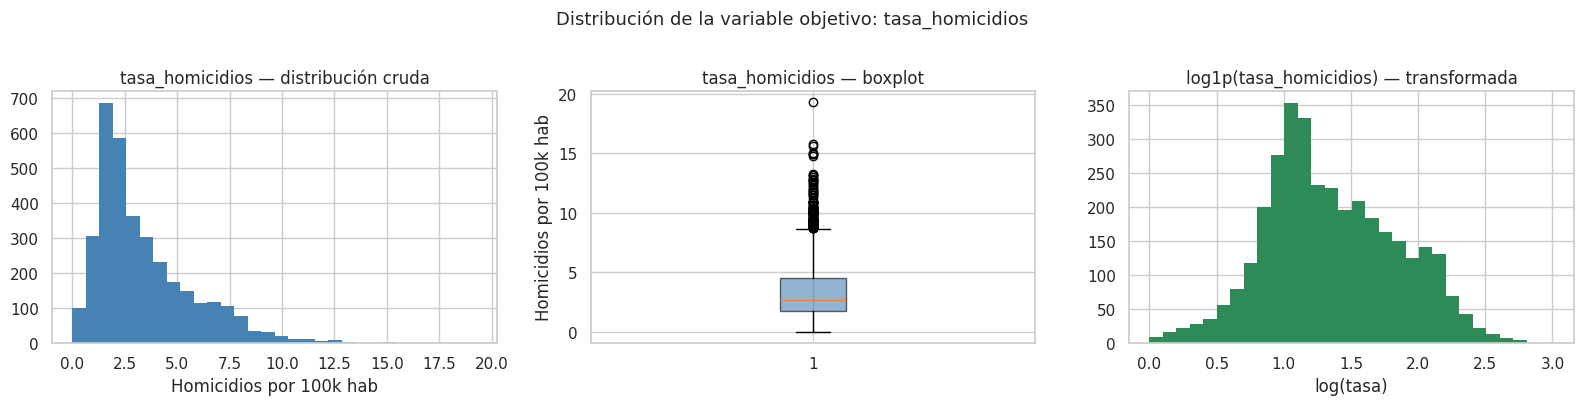

Skewness (sesgo): 1.4212
Media   : 3.41
Mediana : 2.64
Máximo  : 19.29
Mínimo  : 0.00


In [25]:
# ── 1.2 DISTRIBUCIÓN DE tasa_homicidios ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribución cruda
axes[0].hist(df['tasa_homicidios'], bins=30, color='steelblue', edgecolor='none')
axes[0].set_title("tasa_homicidios — distribución cruda")
axes[0].set_xlabel("Homicidios por 100k hab")

# 2. Boxplot para detectar outliers
axes[1].boxplot(df['tasa_homicidios'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title("tasa_homicidios — boxplot")
axes[1].set_ylabel("Homicidios por 100k hab")

# 3. Log-transform
axes[2].hist(np.log1p(df['tasa_homicidios']), bins=30,
             color='seagreen', edgecolor='none')
axes[2].set_title("log1p(tasa_homicidios) — transformada")
axes[2].set_xlabel("log(tasa)")

plt.suptitle("Distribución de la variable objetivo: tasa_homicidios",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Estadísticos clave
skew = df['tasa_homicidios'].skew()
print(f"Skewness (sesgo): {skew:.4f}")
print(f"Media   : {df['tasa_homicidios'].mean():.2f}")
print(f"Mediana : {df['tasa_homicidios'].median():.2f}")
print(f"Máximo  : {df['tasa_homicidios'].max():.2f}")
print(f"Mínimo  : {df['tasa_homicidios'].min():.2f}")

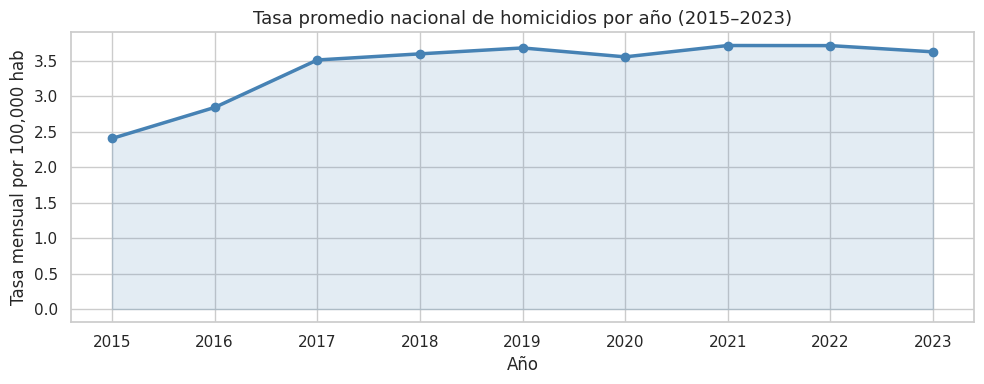

In [26]:
# ── Evolución de la tasa promedio nacional por año ─────────────────────
df_anual = df.groupby('Año')['tasa_homicidios'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(df_anual['Año'], df_anual['tasa_homicidios'],
         marker='o', linewidth=2.5, color='steelblue')
plt.fill_between(df_anual['Año'], df_anual['tasa_homicidios'],
                 alpha=0.15, color='steelblue')
plt.title("Tasa promedio nacional de homicidios por año (2015–2023)", fontsize=13)
plt.xlabel("Año")
plt.ylabel("Tasa mensual por 100,000 hab")
plt.xticks(df_anual['Año'])
plt.tight_layout()
plt.show()

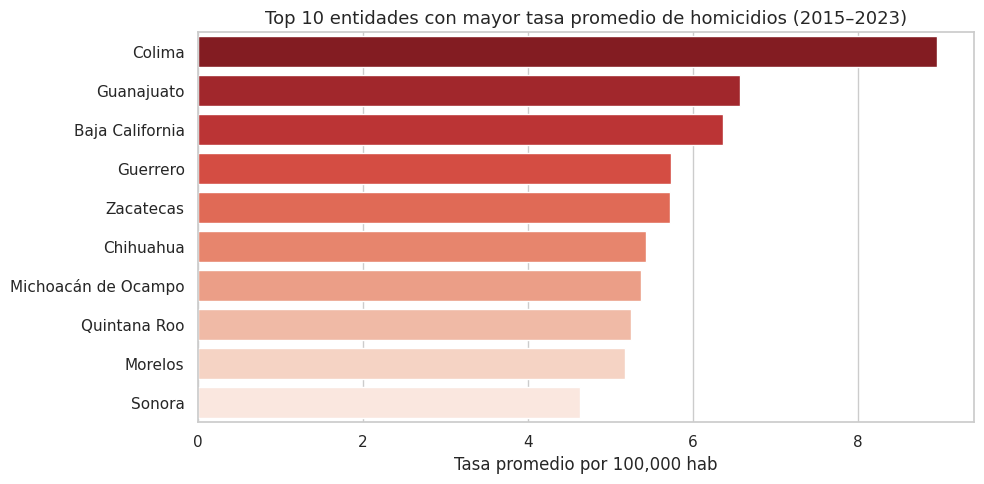

In [27]:
# ── Top 10 entidades con mayor tasa promedio 2015–2023 ────────────────
df_ent = (df.groupby('Entidad')['tasa_homicidios']
            .mean()
            .sort_values(ascending=False)
            .head(10)
            .reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=df_ent, x='tasa_homicidios', y='Entidad',
            palette='Reds_r', hue='Entidad', legend=False)
plt.title("Top 10 entidades con mayor tasa promedio de homicidios (2015–2023)",
          fontsize=13)
plt.xlabel("Tasa promedio por 100,000 hab")
plt.ylabel("")
plt.tight_layout()
plt.show()

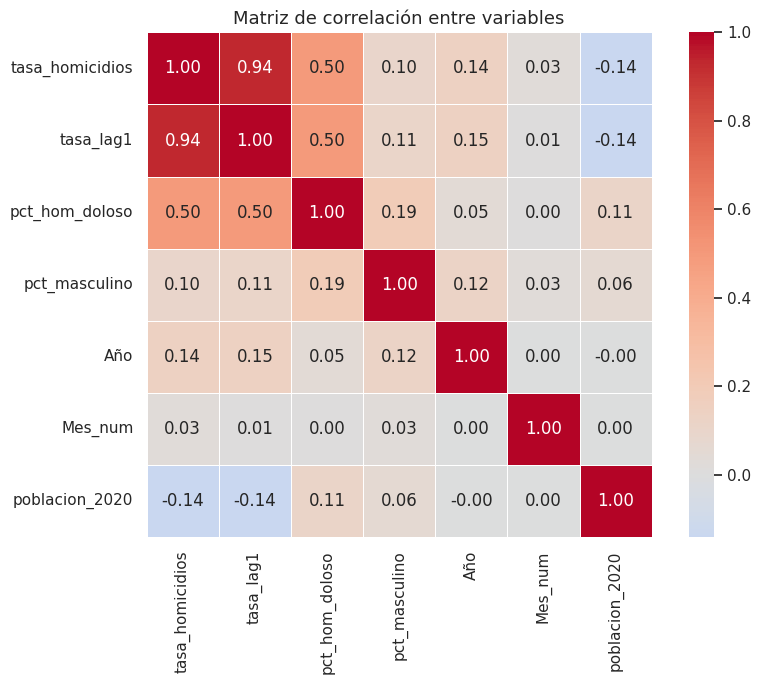

In [28]:
# ── Matriz de correlación ─────────────────────────────────────────────
cols_corr = ['tasa_homicidios','tasa_lag1','pct_hom_doloso',
             'pct_masculino','Año','Mes_num','poblacion_2020']

corr = df[cols_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title("Matriz de correlación entre variables", fontsize=13)
plt.tight_layout()
plt.show()

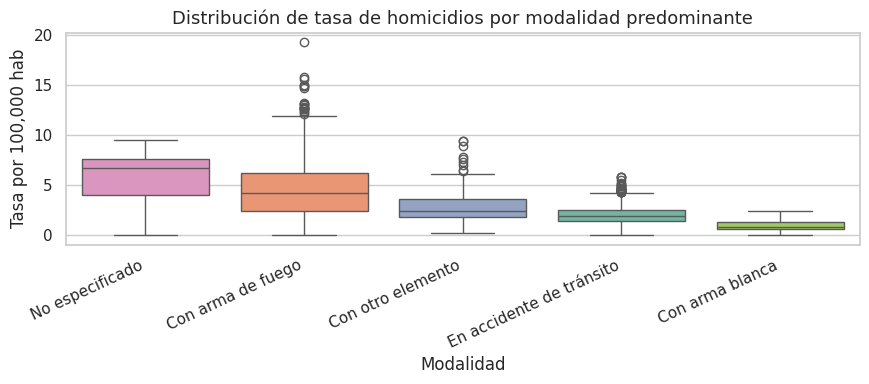

In [29]:
# ── Tasa de homicidios según modalidad predominante ───────────────────
plt.figure(figsize=(9, 4))
order = (df.groupby('modalidad_moda')['tasa_homicidios']
           .median()
           .sort_values(ascending=False)
           .index)

sns.boxplot(data=df, x='modalidad_moda', y='tasa_homicidios',
            order=order, palette='Set2',
            hue='modalidad_moda', legend=False)
plt.title("Distribución de tasa de homicidios por modalidad predominante",
          fontsize=13)
plt.xlabel("Modalidad")
plt.ylabel("Tasa por 100,000 hab")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# **Sección 2 — Preprocesamiento**

## Estrategia de estimación del error

Se utilizará **Hold-Out** con división 80/20 (entrenamiento/prueba), con
`random_state=42` para reproducibilidad. Aunque el dataset tiene 3,456 registros
— un volumen moderado — el Hold-Out sigue siendo válido porque el conjunto de
prueba resultante (~691 registros) es estadísticamente representativo y cubre
entidades y periodos no vistos en entrenamiento. Cross-Validation con `KFold k=5`
se reserva exclusivamente para la búsqueda de hiperparámetros en la Sección 4.

## Consideración crítica: Data Leakage

Todos los transformadores (imputadores, escaladores, encoders) serán ajustados
**exclusivamente sobre el conjunto de entrenamiento** (`X_train`) y aplicados
sobre el de prueba (`X_test`). Esto se garantiza construyendo un `Pipeline` de
sklearn, que encapsula cada transformación y previene cualquier fuga de información
del conjunto de prueba hacia el entrenamiento.

Adicionalmente, las columnas `total_victimas` y `poblacion_2020` serán eliminadas
antes de la división train/test — son insumos directos del cálculo de
`tasa_homicidios` y su inclusión como features constituiría data leakage directo.

## Decisiones de transformación

- **Valores faltantes numéricos:** imputación por **mediana agrupada por entidad**
  — robusta ante los outliers presentes en la tasa de homicidios, y respeta la
  heterogeneidad entre estados (Colima tiene una distribución muy distinta a
  Yucatán).
- **Valores faltantes categóricos:** imputación por **moda** — los 9 nulos en
  `modalidad_moda` corresponden a meses con cero víctimas; la moda preserva la
  categoría más frecuente sin introducir categorías artificiales.
- **Escalado numérico:** `StandardScaler` — requerido para Ridge Regression, ya
  que la regularización L2 es sensible a la escala de las variables. Random Forest
  no lo requiere, pero al estar dentro del mismo pipeline no le afecta.
- **Codificación categórica:** `OneHotEncoder` con `handle_unknown='ignore'` —
  aplicado sobre `Entidad`, `Mes` y `modalidad_moda`. Evita errores si el conjunto
  de prueba contiene categorías no vistas en entrenamiento.
- **Transformación de la variable objetivo:** `log1p(tasa_homicidios)` — corrige
  el sesgo positivo (skewness = 1.42) y estabiliza la varianza, mejorando la
  performance de modelos lineales como Ridge. Las métricas finales se reportarán
  en escala original aplicando `expm1` sobre las predicciones.

In [30]:
# ── 2.1 PREPARACIÓN DE FEATURES ───────────────────────────────────────────────

# Eliminar columnas que causan data leakage o no son predictoras
drop_cols = ['total_victimas', 'poblacion_2020', 'Clave_Ent']
df_model = df.drop(columns=drop_cols).copy()

# Variable objetivo — aplicar log1p
df_model['target'] = np.log1p(df_model['tasa_homicidios'])

# Separar features y target
X = df_model.drop(columns=['tasa_homicidios', 'target'])
y = df_model['target']

# Definir tipos de columnas
num_cols = ['Año', 'Mes_num', 'pct_hom_doloso', 'pct_masculino', 'tasa_lag1']
cat_cols = ['Entidad', 'Mes', 'modalidad_moda']

print("── Features numéricas ──────────────────────────────────────────────────")
print(num_cols)
print("\n── Features categóricas ──────────────────────────────────────────────")
print(cat_cols)
print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\n── Nulos en X ───────────────────────────────────────────────────────")
print(f"{X.isnull().sum()[X.isnull().sum() > 0]}")

── Features numéricas ──────────────────────────────────────────────────
['Año', 'Mes_num', 'pct_hom_doloso', 'pct_masculino', 'tasa_lag1']

── Features categóricas ──────────────────────────────────────────────
['Entidad', 'Mes', 'modalidad_moda']

Shape de X: (3456, 8)
Shape de y: (3456,)

── Nulos en X ───────────────────────────────────────────────────────
pct_hom_doloso     9
pct_masculino      9
tasa_lag1         32
dtype: int64


In [31]:
# ── 2.2 IMPUTACIÓN AGRUPADA POR ENTIDAD ───────────────────────────────────────
# Los nulos en tasa_lag1, pct_hom_doloso y pct_masculino se imputan
# con la mediana de cada entidad — respeta heterogeneidad entre estados

for col in ['tasa_lag1', 'pct_hom_doloso', 'pct_masculino']:
    mediana_entidad = X.groupby('Entidad')[col].transform('median')
    X[col] = X[col].fillna(mediana_entidad)

print(f"Imputación completada")
print(f"\nNulos totales: {X.isnull().sum().sum()}")

Imputación completada

Nulos totales: 0


In [32]:
# ── 2.3 HOLD-OUT 80/20 ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Split completado")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

Split completado
X_train : (2764, 8)
X_test  : (692, 8)
y_train : (2764,)
y_test  : (692,)


In [33]:
# ── 2.4 PIPELINE ──────────────────────────────────────────────────────────────

# Transformador numérico — imputación por mediana + escalado
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Transformador categórico — imputación por moda + OHE
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer — aplica cada transformador a sus columnas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print("Pipeline de preprocesamiento construido")
print("\n── Transformaciones ────────────────────────────────────────────────────")
print(f"Numéricas  {num_cols} → SimpleImputer(median) + StandardScaler")
print(f"Categóricas {cat_cols} → SimpleImputer(most_frequent) + OneHotEncoder")

Pipeline de preprocesamiento construido

── Transformaciones ────────────────────────────────────────────────────
Numéricas  ['Año', 'Mes_num', 'pct_hom_doloso', 'pct_masculino', 'tasa_lag1'] → SimpleImputer(median) + StandardScaler
Categóricas ['Entidad', 'Mes', 'modalidad_moda'] → SimpleImputer(most_frequent) + OneHotEncoder


In [34]:
# ── 2.5 VERIFICACIÓN — ajustar SOLO sobre X_train ────────────────────────────
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f"── Preprocesador ajustado sobre X_train únicamente ────────────────────")
print(f"X_train transformado : {X_train_prep.shape}")
print(f"X_test  transformado : {X_test_prep.shape}")
print(f"\nColumnas resultantes : {X_train_prep.shape[1]}")
print(f"(5 numéricas + OHE expandido de {len(cat_cols)} categóricas)")

── Preprocesador ajustado sobre X_train únicamente ────────────────────
X_train transformado : (2764, 54)
X_test  transformado : (692, 54)

Columnas resultantes : 54
(5 numéricas + OHE expandido de 3 categóricas)


# **Sección 3 — Modelos y Justificación**

Se entrenaron dos modelos de **naturaleza distinta** como línea base con
hiperparámetros por defecto:

## Modelo 1: Ridge Regression
Modelo lineal con regularización L2. Supone que la relación entre las variables
predictoras y la tasa de homicidios es aproximadamente lineal. Su fortaleza es la
interpretabilidad y la velocidad de entrenamiento — relevante aquí porque permite
identificar qué entidades y modalidades tienen mayor peso en la predicción. La
regularización L2 penaliza coeficientes grandes, lo que reduce el overfitting
en un dataset de tamaño moderado como el nuestro (3,456 registros). Es el punto
de comparación base: establece cuánto se puede explicar asumiendo relaciones
lineales entre los features y la violencia homicida.

## Modelo 2: Random Forest Regressor
Modelo de ensamble basado en árboles de decisión. No asume linealidad y captura
interacciones complejas entre variables — por ejemplo, que el efecto de
`pct_hom_doloso` sobre la tasa depende del estado y del año, o que ciertos meses
en entidades específicas tienen patrones que un modelo lineal no puede capturar.
Es robusto ante los outliers presentes en `tasa_homicidios` (máximo 19.29) y
ante variables de distinta escala. Representa la contraparte no lineal necesaria
para determinar si la complejidad adicional se traduce en mejor desempeño
predictivo frente a Ridge.

La comparación entre ambos permite responder: ¿la relación entre el perfil
de violencia de una entidad y su tasa mensual de homicidios es suficientemente
capturada con un modelo lineal, o requiere un modelo que aprenda interacciones
no lineales entre entidad, temporalidad y modalidad del delito?

In [35]:
# ── 3.1 MODELO BASE 1: RIDGE REGRESSION ──────────────────────────────────────
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        Ridge())
])

pipeline_ridge.fit(X_train, y_train)

y_pred_ridge = pipeline_ridge.predict(X_test)

# Métricas en escala original (expm1 revierte el log1p)
y_test_orig        = np.expm1(y_test)
y_pred_ridge_orig  = np.expm1(y_pred_ridge)

rmse_ridge = np.sqrt(mean_squared_error(y_test_orig, y_pred_ridge_orig))
mae_ridge  = mean_absolute_error(y_test_orig, y_pred_ridge_orig)
r2_ridge   = r2_score(y_test_orig, y_pred_ridge_orig)

print("── Ridge Regression (base) ─────────────────────────────────────────────")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"MAE  : {mae_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

── Ridge Regression (base) ─────────────────────────────────────────────
RMSE : 0.8669
MAE  : 0.5592
R²   : 0.8673


In [36]:
# ── 3.2 MODELO BASE 2: RANDOM FOREST REGRESSOR ───────────────────────────────
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        RandomForestRegressor(random_state=42))
])

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

y_pred_rf_orig = np.expm1(y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf_orig))
mae_rf  = mean_absolute_error(y_test_orig, y_pred_rf_orig)
r2_rf   = r2_score(y_test_orig, y_pred_rf_orig)

print("── Random Forest Regressor (base) ──────────────────────────────────────")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

── Random Forest Regressor (base) ──────────────────────────────────────
RMSE : 0.7327
MAE  : 0.5254
R²   : 0.9052


── Comparativa modelos base ─────────────────────────────────────────────
              Modelo   RMSE    MAE     R²
        Ridge (base) 0.8669 0.5592 0.8673
Random Forest (base) 0.7327 0.5254 0.9052


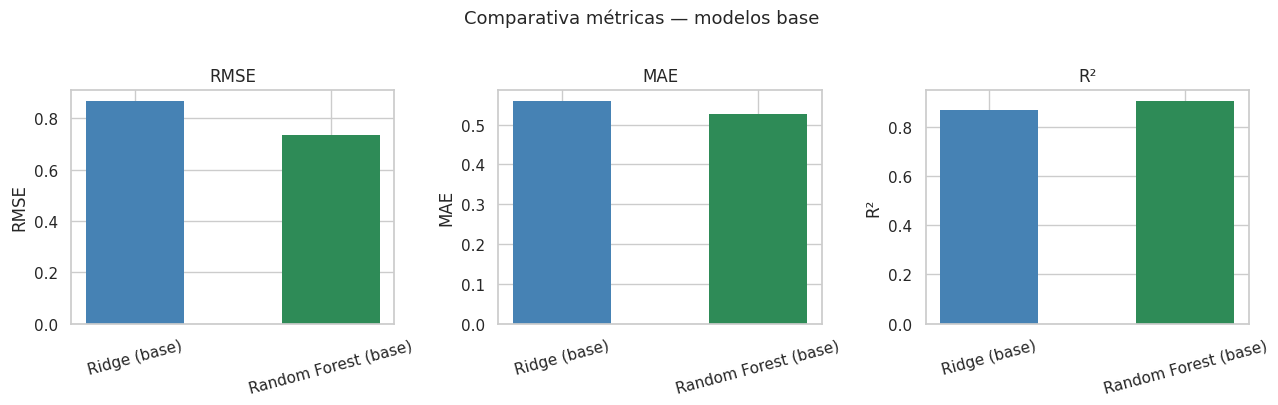

In [37]:
# ── 3.3 COMPARATIVA MODELOS BASE ─────────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo'   : ['Ridge (base)', 'Random Forest (base)'],
    'RMSE'     : [rmse_ridge, rmse_rf],
    'MAE'      : [mae_ridge,  mae_rf],
    'R²'       : [r2_ridge,   r2_rf]
})

print("── Comparativa modelos base ─────────────────────────────────────────────")
print(resultados.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metricas = ['RMSE', 'MAE', 'R²']
colores  = ['steelblue', 'seagreen']

for i, metrica in enumerate(metricas):
    axes[i].bar(resultados['Modelo'], resultados[metrica],
                color=colores, edgecolor='none', width=0.5)
    axes[i].set_title(metrica, fontsize=12)
    axes[i].set_ylabel(metrica)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle("Comparativa métricas — modelos base", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# **Sección 4 — Optimización de Hiperparámetros**

## Estrategia de validación interna

Se utiliza **`KFold(n_splits=5)`** sobre el conjunto de entrenamiento (2,764
registros). Cinco folds ofrecen un balance adecuado entre varianza del estimador
y costo computacional para este tamaño de dataset.

## Métrica de optimización

**RMSE negativo** (`neg_root_mean_squared_error`) — penaliza más los errores
grandes, lo cual es deseable en predicción de tasas de homicidio donde una
estimación muy alejada del valor real tiene mayor impacto en decisiones de
política pública que varios errores pequeños.

## Espacio de búsqueda

### Ridge — GridSearchCV
Se usa búsqueda exhaustiva dado que el espacio es pequeño (un solo
hiperparámetro). Se exploran valores de `alpha` en escala logarítmica para
cubrir varios órdenes de magnitud:
- `alpha` — controla la intensidad de la regularización L2. Un valor bajo
  se acerca a regresión lineal simple; un valor alto penaliza fuertemente
  los coeficientes, reduciendo overfitting a costa de mayor sesgo.

### Random Forest — RandomizedSearchCV
Se usa búsqueda aleatoria dado el tamaño del espacio de combinaciones.
Se fija `n_iter=30` para balancear exploración y tiempo de cómputo:
- `n_estimators` — número de árboles. Más árboles reducen varianza pero
  aumentan tiempo de cómputo.
- `max_depth` — profundidad máxima de cada árbol. Controla el balance
  bias-varianza: árboles muy profundos overfittean, muy superficiales
  underfittean.
- `min_samples_split` — mínimo de muestras para dividir un nodo. Valores
  mayores actúan como regularización implícita, útil dado el tamaño
  moderado del dataset.
- `max_features` — número de features evaluados en cada split. Reduce
  correlación entre árboles y mejora la generalización del ensamble.

In [38]:
# ── 4.1 GRIDSEARCHCV — RIDGE ──────────────────────────────────────────────────
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000]
}

gs_ridge = GridSearchCV(
    estimator  = pipeline_ridge,
    param_grid = param_grid_ridge,
    cv         = kf,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

gs_ridge.fit(X_train, y_train)

print(f"\nRidge — mejores hiperparámetros : {gs_ridge.best_params_}")
print(f"RMSE CV (train)                 : {-gs_ridge.best_score_:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits

Ridge — mejores hiperparámetros : {'model__alpha': 1}
RMSE CV (train)                 : 0.1824


In [20]:
# ── 4.2 RANDOMIZEDSEARCHCV — RANDOM FOREST ───────────────────────────────────
from scipy.stats import randint

param_dist_rf = {
    'model__n_estimators'    : randint(100, 500),
    'model__max_depth'       : [None, 5, 10, 15, 20],
    'model__min_samples_split': randint(2, 20),
    'model__max_features'    : ['sqrt', 'log2', 0.5, 0.8]
}

rs_rf = RandomizedSearchCV(
    estimator          = pipeline_rf,
    param_distributions= param_dist_rf,
    n_iter             = 30,
    cv                 = kf,
    scoring            = 'neg_root_mean_squared_error',
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)

rs_rf.fit(X_train, y_train)

print(f"\nRandom Forest — mejores hiperparámetros : {rs_rf.best_params_}")
print(f"RMSE CV (train)                         : {-rs_rf.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Forest — mejores hiperparámetros : {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_split': 8, 'model__n_estimators': 373}
RMSE CV (train)                         : 0.1657


In [39]:
# ── 4.3 EVALUACIÓN MODELOS OPTIMIZADOS ───────────────────────────────────────

# Ridge optimizado
y_pred_ridge_opt      = gs_ridge.best_estimator_.predict(X_test)
y_pred_ridge_opt_orig = np.expm1(y_pred_ridge_opt)

rmse_ridge_opt = np.sqrt(mean_squared_error(y_test_orig, y_pred_ridge_opt_orig))
mae_ridge_opt  = mean_absolute_error(y_test_orig, y_pred_ridge_opt_orig)
r2_ridge_opt   = r2_score(y_test_orig, y_pred_ridge_opt_orig)

# Random Forest optimizado
y_pred_rf_opt      = rs_rf.best_estimator_.predict(X_test)
y_pred_rf_opt_orig = np.expm1(y_pred_rf_opt)

rmse_rf_opt = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf_opt_orig))
mae_rf_opt  = mean_absolute_error(y_test_orig, y_pred_rf_opt_orig)
r2_rf_opt   = r2_score(y_test_orig, y_pred_rf_opt_orig)

print("── Ridge optimizado ────────────────────────────────────────────────────")
print(f"RMSE : {rmse_ridge_opt:.4f}")
print(f"MAE  : {mae_ridge_opt:.4f}")
print(f"R²   : {r2_ridge_opt:.4f}")

print("\n── Random Forest optimizado ────────────────────────────────────────────")
print(f"RMSE : {rmse_rf_opt:.4f}")
print(f"MAE  : {mae_rf_opt:.4f}")
print(f"R²   : {r2_rf_opt:.4f}")

── Ridge optimizado ────────────────────────────────────────────────────
RMSE : 0.8669
MAE  : 0.5592
R²   : 0.8673

── Random Forest optimizado ────────────────────────────────────────────
RMSE : 0.6999
MAE  : 0.4887
R²   : 0.9135


── Comparativa completa ─────────────────────────────────────────────────
                    Modelo   RMSE    MAE     R²
              Ridge (base) 0.8669 0.5592 0.8673
        Ridge (optimizado) 0.8669 0.5592 0.8673
      Random Forest (base) 0.7327 0.5254 0.9052
Random Forest (optimizado) 0.6999 0.4887 0.9135


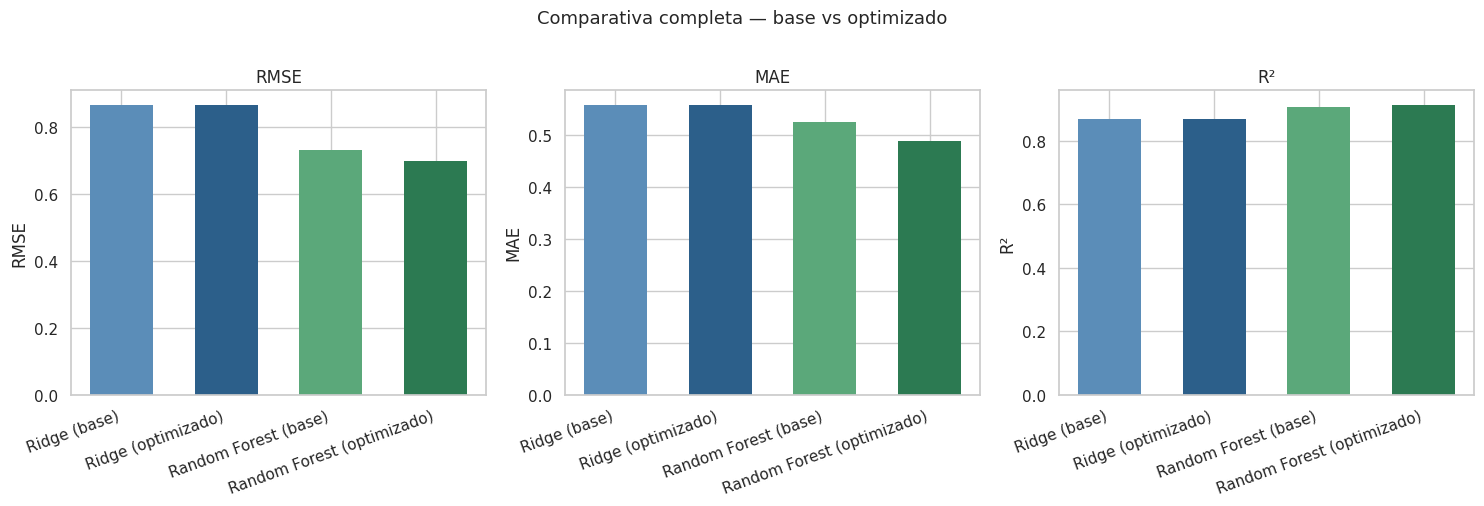

In [40]:
# ── 4.4 COMPARATIVA COMPLETA ──────────────────────────────────────────────────
comparativa = pd.DataFrame({
    'Modelo': [
        'Ridge (base)', 'Ridge (optimizado)',
        'Random Forest (base)', 'Random Forest (optimizado)'
    ],
    'RMSE': [rmse_ridge,     rmse_ridge_opt,
             rmse_rf,        rmse_rf_opt],
    'MAE' : [mae_ridge,      mae_ridge_opt,
             mae_rf,         mae_rf_opt],
    'R²'  : [r2_ridge,       r2_ridge_opt,
             r2_rf,          r2_rf_opt]
})

print("── Comparativa completa ─────────────────────────────────────────────────")
print(comparativa.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = ['RMSE', 'MAE', 'R²']
colores  = ['#5b8db8', '#2c5f8a', '#5ba87a', '#2c7a52']

for i, metrica in enumerate(metricas):
    axes[i].bar(comparativa['Modelo'], comparativa[metrica],
                color=colores, edgecolor='none', width=0.6)
    axes[i].set_title(metrica, fontsize=12)
    axes[i].set_ylabel(metrica)
    axes[i].tick_params(axis='x', rotation=20)
    for tick in axes[i].get_xticklabels():
        tick.set_ha('right')

plt.suptitle("Comparativa completa — base vs optimizado", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# **Sección 5 — Evaluación Robusta**

## Métricas seleccionadas

Para este problema de regresión sobre tasas de homicidio se reportan tres
métricas complementarias. Todas se calculan en escala original (homicidios
por 100,000 habitantes) aplicando `expm1` sobre las predicciones
log-transformadas:

- **RMSE (Root Mean Squared Error):** error en la misma unidad que
  `tasa_homicidios` (homicidios por 100k hab). Penaliza errores grandes —
  relevante porque una estimación muy errónea en una entidad de alto riesgo
  puede traducirse en asignación incorrecta de recursos de seguridad.

- **MAE (Mean Absolute Error):** error promedio absoluto en homicidios por
  100k hab. Más interpretable para el usuario final: "en promedio, el modelo
  estima la tasa con un error de X homicidios por cada 100,000 habitantes".

- **R² (Coeficiente de determinación):** proporción de la varianza de la
  tasa de homicidios explicada por el modelo. Permite comparar modelos
  independientemente de la escala y responder qué tan bien cada modelo
  captura el comportamiento de la violencia homicida entre entidades y meses.

## Nota sobre Ridge optimizado

La búsqueda de hiperparámetros encontró que el valor óptimo de `alpha` es 1,
que coincide con el valor por defecto de sklearn. Esto indica que Ridge ya
estaba bien configurado en su versión base y que la regularización L2 con
ese valor es la más adecuada para este dataset. No es un error — es un
resultado válido que confirma que el modelo lineal alcanzó su techo de
desempeño con la configuración estándar.

In [41]:
# ── 5.1 TABLA COMPARATIVA FINAL ───────────────────────────────────────────────
tabla_final = pd.DataFrame({
    'Modelo': [
        'Ridge (base)',
        'Ridge (optimizado)',
        'Random Forest (base)',
        'Random Forest (optimizado)'
    ],
    'RMSE': [rmse_ridge,     rmse_ridge_opt,  rmse_rf,  rmse_rf_opt],
    'MAE' : [mae_ridge,      mae_ridge_opt,   mae_rf,   mae_rf_opt],
    'R²'  : [r2_ridge,       r2_ridge_opt,    r2_rf,    r2_rf_opt]
}).set_index('Modelo')

print("── Tabla comparativa final (escala original — homicidios por 100k hab) ──")
print(tabla_final.to_string())

mejor_modelo = tabla_final['RMSE'].idxmin()
print(f"\nMejor modelo por RMSE: {mejor_modelo}")

── Tabla comparativa final (escala original — homicidios por 100k hab) ──
                             RMSE    MAE     R²
Modelo                                         
Ridge (base)               0.8669 0.5592 0.8673
Ridge (optimizado)         0.8669 0.5592 0.8673
Random Forest (base)       0.7327 0.5254 0.9052
Random Forest (optimizado) 0.6999 0.4887 0.9135

Mejor modelo por RMSE: Random Forest (optimizado)


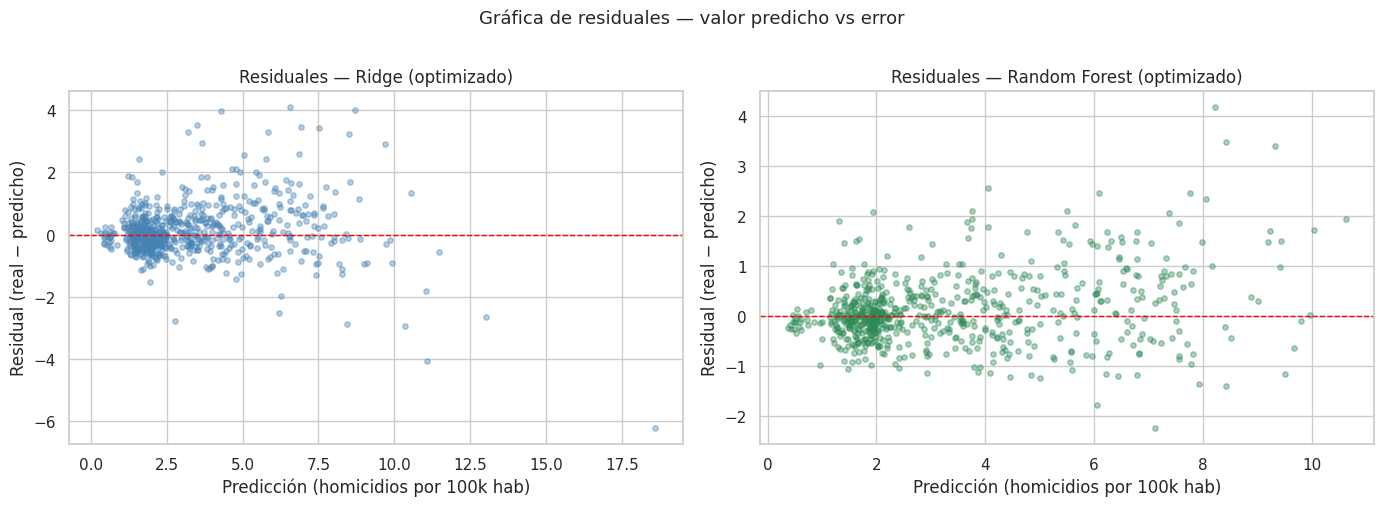

In [ ]:
# ── 5.2 GRÁFICA DE RESIDUALES ─────────────────────────────────────────────────
residuales_ridge = y_test_orig.values - y_pred_ridge_opt_orig
residuales_rf    = y_test_orig.values - y_pred_rf_opt_orig

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].scatter(y_pred_ridge_opt_orig, residuales_ridge,
                alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title("Residuales — Ridge (optimizado)", fontsize=12)
axes[0].set_xlabel("Predicción (homicidios por 100k hab)")
axes[0].set_ylabel("Residual (real − predicho)")

# Random Forest
axes[1].scatter(y_pred_rf_opt_orig, residuales_rf,
                alpha=0.4, s=15, color='seagreen')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title("Residuales — Random Forest (optimizado)", fontsize=12)
axes[1].set_xlabel("Predicción (homicidios por 100k hab)")
axes[1].set_ylabel("Residual (real − predicho)")

plt.suptitle("Gráfica de residuales — valor predicho vs error",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

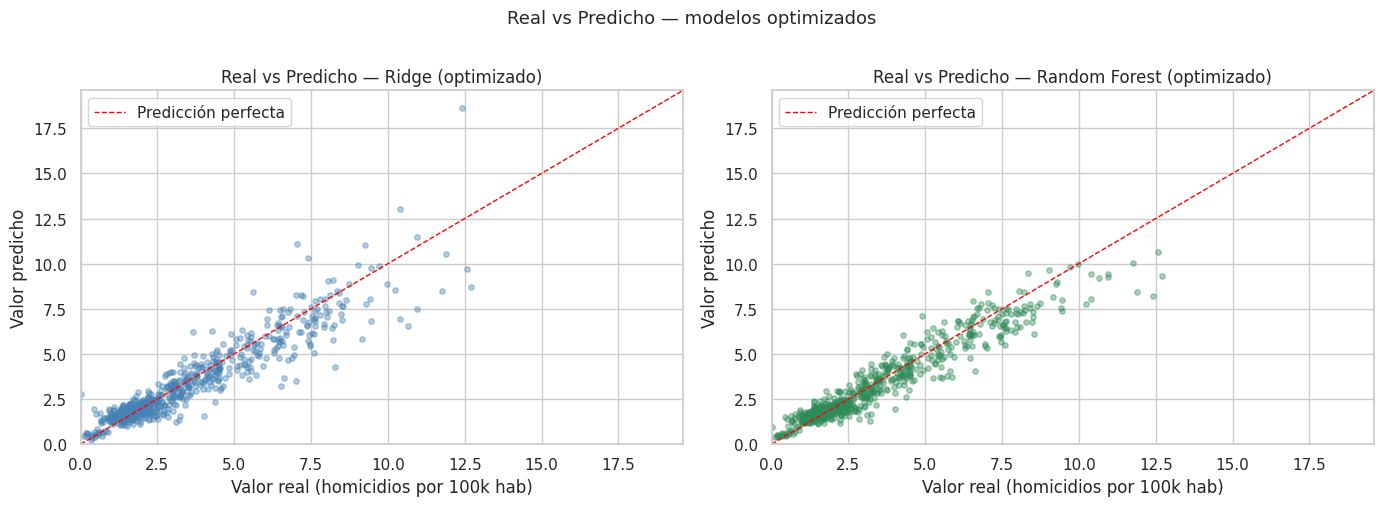

In [ ]:
# ── 5.3 REAL VS PREDICHO ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lim_max = max(y_test_orig.max(),
              y_pred_ridge_opt_orig.max(),
              y_pred_rf_opt_orig.max()) + 1

for ax, y_pred, titulo, color in zip(
    axes,
    [y_pred_ridge_opt_orig, y_pred_rf_opt_orig],
    ['Ridge (optimizado)', 'Random Forest (optimizado)'],
    ['steelblue', 'seagreen']
):
    ax.scatter(y_test_orig, y_pred, alpha=0.4, s=15, color=color)
    ax.plot([0, lim_max], [0, lim_max], color='red',
            linestyle='--', linewidth=1, label='Predicción perfecta')
    ax.set_title(f"Real vs Predicho — {titulo}", fontsize=12)
    ax.set_xlabel("Valor real (homicidios por 100k hab)")
    ax.set_ylabel("Valor predicho")
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)
    ax.legend()

plt.suptitle("Real vs Predicho — modelos optimizados",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

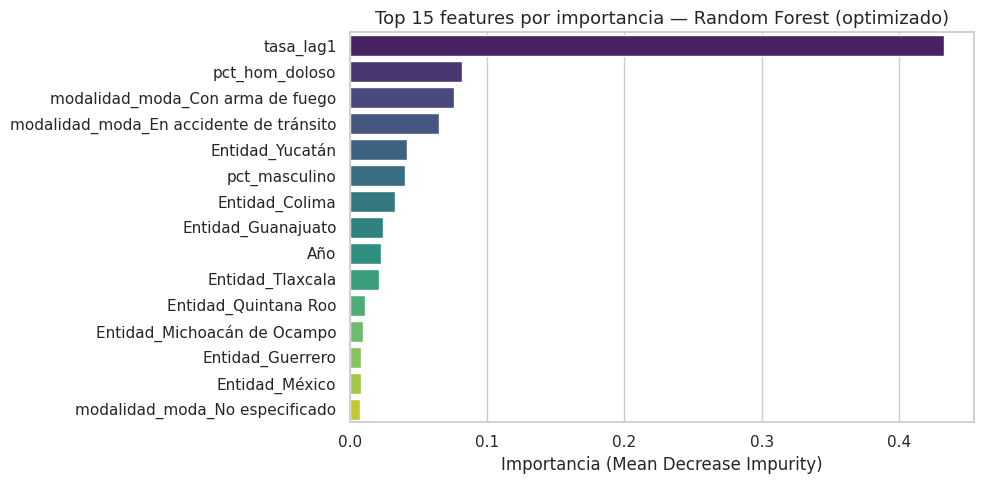

                                feature  importancia
                              tasa_lag1       0.4329
                         pct_hom_doloso       0.0819
       modalidad_moda_Con arma de fuego       0.0759
modalidad_moda_En accidente de tránsito       0.0648
                        Entidad_Yucatán       0.0419
                          pct_masculino       0.0402
                         Entidad_Colima       0.0330
                     Entidad_Guanajuato       0.0245
                                    Año       0.0226
                       Entidad_Tlaxcala       0.0215
                   Entidad_Quintana Roo       0.0110
            Entidad_Michoacán de Ocampo       0.0095
                       Entidad_Guerrero       0.0085
                         Entidad_México       0.0079
         modalidad_moda_No especificado       0.0075


In [ ]:
# ── 5.4 IMPORTANCIA DE FEATURES ───────────────────────────────────────────────
best_rf    = rs_rf.best_estimator_
rf_model   = best_rf.named_steps['model']
ohe_cols   = (best_rf.named_steps['preprocessor']
              .named_transformers_['cat']
              .named_steps['ohe']
              .get_feature_names_out(cat_cols))

feature_names = num_cols + list(ohe_cols)
importancias  = rf_model.feature_importances_

df_imp = (pd.DataFrame({'feature': feature_names, 'importancia': importancias})
          .sort_values('importancia', ascending=False)
          .head(15)
          .reset_index(drop=True))

plt.figure(figsize=(10, 5))
sns.barplot(data=df_imp, x='importancia', y='feature',
            palette='viridis', hue='feature', legend=False)
plt.title("Top 15 features por importancia — Random Forest (optimizado)",
          fontsize=13)
plt.xlabel("Importancia (Mean Decrease Impurity)")
plt.ylabel("")
plt.tight_layout()
plt.show()

print(df_imp.to_string(index=False))

# **Sección 6 — Conclusiones**

## Respuesta a la pregunta de negocio

La pregunta planteada fue: *¿Cuál será la tasa de homicidios por cada 100,000
habitantes en una entidad federativa de México, dado su historial de violencia,
modalidad del delito, perfil de las víctimas y contexto temporal?*

El modelo **Random Forest (optimizado)** responde esta pregunta con un R² de
0.9135, lo que significa que explica el 91.35% de la varianza en la tasa
mensual de homicidios entre entidades. Con un MAE de 0.4887 homicidios por
100,000 habitantes, el modelo estima la tasa mensual con un error promedio
menor a medio homicidio por cada 100,000 habitantes — un nivel de precisión
aceptable para orientar decisiones de política pública y asignación de
recursos de seguridad.

El feature más importante fue `tasa_lag1` (importancia 0.43), confirmando
que el mejor predictor de la violencia de un mes es la violencia del mes
anterior. Le siguen `pct_hom_doloso` (0.08) y la modalidad con arma de
fuego (0.076), lo que indica que tanto la intencionalidad como el tipo de
arma son señales estructurales de la violencia en una entidad.

## Confiabilidad del modelo para producción

El modelo es **prometedor pero no suficiente para producción** en su estado
actual por las siguientes razones:

- R² de 0.91 es sólido, pero el RMSE de 0.70 en escala original implica
  errores que en entidades extremas como Colima (tasa ~9 mensual) pueden
  representar desviaciones significativas.
- El modelo fue entrenado con datos 2015–2023 y usa población del Censo
  2020 como constante — no captura cambios demográficos reales año a año.
- La gráfica de residuales de Ridge muestra heterocedasticidad clara
  (los errores crecen con el valor predicho), lo que indica que el modelo
  lineal subestima sistemáticamente las entidades más violentas. Random
  Forest corrige parcialmente esto pero persisten outliers residuales
  en tasas altas.

## Limitaciones identificadas

- **Población fija:** se usa la población del Censo 2020 para todos los
  años — introduce error en años alejados del censo, especialmente 2015
  y 2023.
- **Dataset pequeño:** 3,456 registros es suficiente para cumplir el
  requisito mínimo, pero limita la capacidad de generalización del modelo
  a patrones no vistos.
- **Sin variables socioeconómicas:** marginación, desempleo, presencia
  del crimen organizado y densidad policial son factores conocidos de la
  violencia homicida que no están en el dataset.
- **Subregistro:** los datos del SESNSP dependen de carpetas de
  investigación abiertas — existe subregistro documentado en estados con
  instituciones más débiles.
- **Lag como feature:** usar `tasa_lag1` introduce dependencia temporal
  que en producción requiere que el mes anterior ya esté disponible para
  hacer la predicción.

## Propuestas de mejora

- Incorporar datos poblacionales anuales de CONAPO en lugar del censo
  fijo 2020 para calcular tasas más precisas.
- Enriquecer el dataset con variables socioeconómicas del INEGI
  (índice de marginación, tasa de desempleo por entidad y año).
- Explorar modelos de series de tiempo por entidad (SARIMA, Prophet)
  o modelos con efectos fijos de panel para explotar mejor la estructura
  longitudinal de los datos.
- Aumentar la granularidad a nivel municipal usando el archivo de
  incidencia delictiva municipal del SESNSP — pasaría de 32 entidades
  a ~2,400 municipios, aumentando significativamente el volumen y la
  utilidad del modelo.
- Evaluar `GradientBoostingRegressor` o `XGBoost` como alternativa a
  Random Forest — típicamente superan en este tipo de datos tabulares
  estructurados.